In [12]:
# import libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras.applications import EfficientNetB0 # type: ignore
from tensorflow.keras.applications.efficientnet import preprocess_input # type: ignore

In [13]:
# select pre-trained model
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
# freeze pre-trained model  
base_model.trainable = False

base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [14]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [15]:
validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [16]:
import os

train_dir = "/mnt/c/Users/MSI/Desktop/task3/Teeth_Dataset/Training"
validation_dir = "/mnt/c/Users/MSI/Desktop/task3/Teeth_Dataset/Validation"
test_dir = "/mnt/c/Users/MSI/Desktop/task3/Teeth_Dataset/Testing"


print(os.listdir(train_dir))
print(os.listdir(validation_dir))
print(os.listdir(test_dir))

['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']


In [17]:
# load data

img_size = (224,224)
batch_size = 32

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

validation_gen = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 3087 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.


In [18]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# labels from training generator
class_labels = train_gen.classes

# calculate weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(class_labels),
    y=class_labels
)

class_weights = dict(
    enumerate(class_weights)
)

print(class_weights)

{0: np.float64(0.91875), 1: np.float64(0.98), 2: np.float64(1.225), 3: np.float64(0.8166666666666667), 4: np.float64(1.3611111111111112), 5: np.float64(0.8166666666666667), 6: np.float64(1.1221374045801527)}


In [19]:
from tensorflow.keras import layers, models # type: ignore


model = models.Sequential([
    
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        7,
        activation="softmax"
    )
])


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,306 (16.71 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0003
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint # type: ignore


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)


model_checkpoint = ModelCheckpoint(
    "best_efficientnet_teeth.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [22]:
history = model.fit(
    train_gen,

    validation_data=validation_gen,

    epochs=30,

    class_weight=class_weights,

    callbacks=[
        early_stopping,
        reduce_lr,
        model_checkpoint
    ]
)

Epoch 1/30


I0000 00:00:1785862307.762596   46408 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1785862313.222752   46613 service.cc:153] XLA service 0x7190b40346a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785862313.222802   46613 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.0)
I0000 00:00:1785862313.402147   46613 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785862314.673191   46613 cuda_dnn.cc:461] Loaded cuDNN version 92500
I0000 00:00:1785862314.942741   46613 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18863__.255
E0000 00:00:1785862318.238339   46613 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup 

15/97 ━━━━━━━━━━━━━━━━━━━━ 56s 693ms/step - accuracy: 0.2542 - loss: 1.8242

I0000 00:00:1785862342.122072   46613 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18863__.255
E0000 00:00:1785862344.702740   46613 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1785862347.467857   46613 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1785862348.479145   46613 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.5115 - loss: 1.2896

E0000 00:00:1785862388.293055   46612 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1785862388.588120   46612 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1785862389.485879   46612 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


97/97 ━━━━━━━━━━━━━━━━━━━━ 88s 677ms/step - accuracy: 0.5115 - loss: 1.2896 - val_accuracy: 0.7014 - val_loss: 0.8784 - learning_rate: 3.0000e-04
Epoch 2/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 37s 375ms/step - accuracy: 0.7266 - loss: 0.8013 - val_accuracy: 0.7899 - val_loss: 0.6405 - learning_rate: 3.0000e-04
Epoch 3/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 36s 369ms/step - accuracy: 0.8008 - loss: 0.6065 - val_accuracy: 0.8414 - val_loss: 0.5114 - learning_rate: 3.0000e-04
Epoch 4/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 409ms/step - accuracy: 0.8419 - loss: 0.4913 - val_accuracy: 0.8901 - val_loss: 0.3941 - learning_rate: 3.0000e-04
Epoch 5/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 42s 428ms/step - accuracy: 0.8821 - loss: 0.4005 - val_accuracy: 0.8911 - val_loss: 0.3610 - learning_rate: 3.0000e-04
Epoch 6/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 412ms/step - accuracy: 0.8986 - loss: 0.3399 - val_accuracy: 0.9397 - val_loss: 0.2772 - learning_rate: 3.0000e-04
Epoch 7/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 34s 350ms/step - accuracy: 0.91

In [23]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

In [25]:
fine_tune_history = model.fit(
    train_gen,

    validation_data=validation_gen,

    epochs=20,

    class_weight=class_weights,

    callbacks=[
        early_stopping,
        reduce_lr,
        model_checkpoint
    ]
)

Epoch 1/20


I0000 00:00:1785863687.101849   46615 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_82346__.283


79/97 ━━━━━━━━━━━━━━━━━━━━ 9s 510ms/step - accuracy: 0.7884 - loss: 0.6275

I0000 00:00:1785863738.167670   46616 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_82346__.283


97/97 ━━━━━━━━━━━━━━━━━━━━ 95s 784ms/step - accuracy: 0.7937 - loss: 0.6084 - val_accuracy: 0.9708 - val_loss: 0.1128 - learning_rate: 1.0000e-05
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 60s 617ms/step - accuracy: 0.8581 - loss: 0.4385 - val_accuracy: 0.9523 - val_loss: 0.1856 - learning_rate: 1.0000e-05
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 51s 525ms/step - accuracy: 0.8753 - loss: 0.3812 - val_accuracy: 0.9455 - val_loss: 0.2106 - learning_rate: 1.0000e-05
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 53s 548ms/step - accuracy: 0.9070 - loss: 0.3221 - val_accuracy: 0.9446 - val_loss: 0.2172 - learning_rate: 5.0000e-06
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 56s 579ms/step - accuracy: 0.9129 - loss: 0.3019 - val_accuracy: 0.9436 - val_loss: 0.2122 - learning_rate: 5.0000e-06
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 55s 567ms/step - accuracy: 0.9193 - loss: 0.2835 - val_accuracy: 0.9446 - val_loss: 0.2098 - learning_rate: 2.5000e-06


In [26]:
test_loss, test_accuracy = model.evaluate(
    test_gen
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 458ms/step - accuracy: 0.9757 - loss: 0.1080
Test Loss: 0.10803442448377609
Test Accuracy: 0.975680947303772


In [27]:
from sklearn.metrics import classification_report

y_true = test_gen.classes

y_pred = model.predict(test_gen)

y_pred_classes = np.argmax(
    y_pred,
    axis=1
)


print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=list(test_gen.class_indices.keys())
    )
)

33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 404ms/step
              precision    recall  f1-score   support

         CaS       0.99      0.98      0.98       160
         CoS       1.00      0.99      1.00       149
         Gum       0.99      0.97      0.98       120
          MC       0.97      0.96      0.97       180
          OC       0.92      0.97      0.95       108
         OLP       0.97      0.97      0.97       180
          OT       0.98      0.98      0.98       131

    accuracy                           0.98      1028
   macro avg       0.97      0.98      0.98      1028
weighted avg       0.98      0.98      0.98      1028



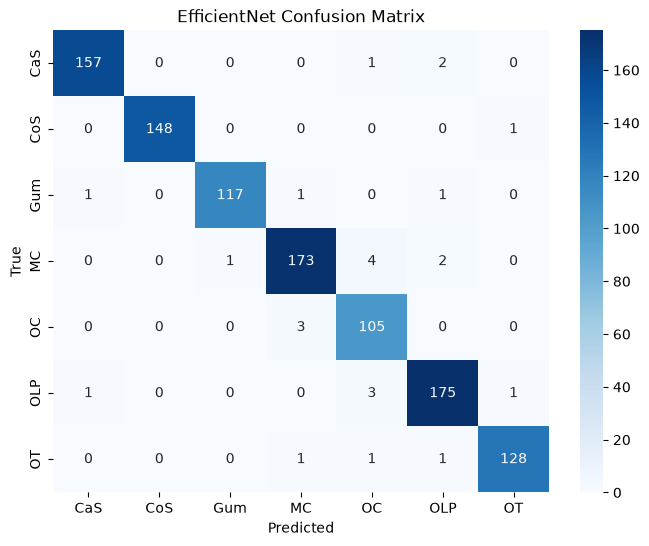

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns 
import matplotlib.pyplot as plt


cm = confusion_matrix(
    y_true,
    y_pred_classes
)


plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_gen.class_indices.keys(),
    yticklabels=test_gen.class_indices.keys()
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("EfficientNet Confusion Matrix")

plt.show()

In [29]:
test_loss, test_accuracy = model.evaluate(test_gen)

print(test_loss)
print(test_accuracy)

33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - accuracy: 0.9757 - loss: 0.1080
0.10803442448377609
0.975680947303772


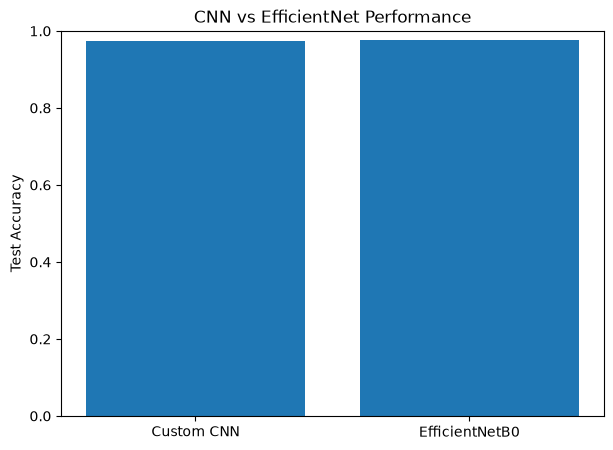

In [32]:
import matplotlib.pyplot as plt

models = [
    "Custom CNN",
    "EfficientNetB0"
]

accuracy = [
    0.9747,
    0.9757 
]


plt.figure(figsize=(7,5))

plt.bar(
    models,
    accuracy
)

plt.ylabel("Test Accuracy")
plt.title("CNN vs EfficientNet Performance")

plt.ylim(0,1)

plt.show()

model.save(
    "best_efficientnet_teeth.keras"
)